# 🏋️‍♀️ 机器学习实战练习：预测员工离职 (Employee Turnover Prediction)

这是你的 **"期中考试"**！📝
这次没有手把手的代码，只有**任务目标**和**数据字典**。
你需要运用在 `User Churn Prediction` 中学到的所有知识，从 0 到 1 构建一个预测模型。

## 1. 任务背景
你刚刚入职一家大型科技公司的 **People Analytics (人力资源数据分析)** 部门。
HR 总监发现最近优秀员工离职率很高，但他不知道是谁，也不知道为什么。
他给了你一份历史数据，希望你能：
1.  **预测**：谁最有可能在下个月离职？
2.  **归因**：为什么他们要走？（是因为钱给少了？还是工作太累了？）

## 2. 数据字典 (Data Dictionary)
- **satisfaction_level**: 员工满意度 (0-1)
- **last_evaluation**: 上次绩效评分 (0-1)
- **number_project**: 负责的项目数量
- **average_montly_hours**: 平均月工作时长
- **time_spend_company**: 在公司呆了几年
- **Work_accident**: 是否发生过工伤 (0/1)
- **promotion_last_5years**: 过去5年是否升职 (0/1)
- **department**: 部门 (Sales, IT, HR, etc.)
- **salary**: 工资等级 (low, medium, high)
- **left**: **[Target]** 是否离职 (1=离职, 0=在职)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 🛠️ 自动生成模拟数据 (运行此 Cell 即可，不需要修改)
# ---------------------------------------------------------
np.random.seed(42)
n_samples = 10000

# 生成特征
satisfaction = np.random.beta(2, 2, n_samples)
last_evaluation = np.random.beta(2, 2, n_samples)
number_project = np.random.randint(2, 8, n_samples)
avg_monthly_hours = np.random.randint(96, 310, n_samples)
time_spend_company = np.random.randint(2, 11, n_samples)
work_accident = np.random.binomial(1, 0.15, n_samples)
promotion = np.random.binomial(1, 0.02, n_samples)
departments = np.random.choice(['Sales', 'IT', 'HR', 'Technical', 'Support', 'Management'], n_samples)
salary = np.random.choice(['low', 'medium', 'high'], n_samples, p=[0.5, 0.4, 0.1])

# 生成 Target (人为制造一些规律，看你的模型能不能发现！)
# 规律1: 满意度低的人容易走
# 规律2: 工作时间太长(过劳)的人容易走
# 规律3: 绩效高但工资低的人容易走
logit = -1.5 + (0.5 - satisfaction) * 3 + (avg_monthly_hours - 200)/100 * 1.5 - (salary == 'high') * 2 
prob = 1 / (1 + np.exp(-logit))
left = np.random.binomial(1, prob)

df = pd.DataFrame({
    'satisfaction_level': satisfaction,
    'last_evaluation': last_evaluation,
    'number_project': number_project,
    'average_montly_hours': avg_monthly_hours,
    'time_spend_company': time_spend_company,
    'Work_accident': work_accident,
    'promotion_last_5years': promotion,
    'department': departments,
    'salary': salary,
    'left': left
})
# ---------------------------------------------------------

print("数据已生成！Shape:", df.shape)
df.head()

数据已生成！Shape: (10000, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left
0,0.615635,0.760338,3,280,5,0,0,IT,medium,0
1,0.499997,0.788399,4,284,3,0,0,Technical,low,1
2,0.618608,0.536543,7,229,6,0,0,IT,low,0
3,0.314110,0.679969,4,139,4,0,0,IT,medium,0
4,0.902516,0.237001,4,284,3,0,0,Technical,medium,0


### 1. 数据概览与清洗 (Data Overview & Cleaning)
**任务**：
1.  检查有没有缺失值？
2.  看看 `left` (离职率) 是多少？(是否存在类别不平衡？)
3.  看看 `salary` 和 `department` 是什么类型？需要处理吗？

In [2]:
# ✍️ 你的代码：检查数据概况
print(df.isnull().sum())
print(df.info())

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
department               0
salary                   0
left                     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     10000 non-null  float64
 1   last_evaluation        10000 non-null  float64
 2   number_project         10000 non-null  int64  
 3   average_montly_hours   10000 non-null  int64  
 4   time_spend_company     10000 non-null  int64  
 5   Work_accident          10000 non-null  int64  
 6   promotion_last_5years  10000 non-null  int64  
 7   department             10000 non-null  object 
 8   salary                 10000 non-null  object 
 9   left                   10000 non

### 2. 探索性数据分析 (EDA)
**任务**：
1.  画一个相关性热力图 (`sns.heatmap`)，看看谁和 `left` 关系最紧密？
2.  (选做) 画一下 `satisfaction_level` 的分布，看看离职和不离职的人有什么区别？

<Axes: >

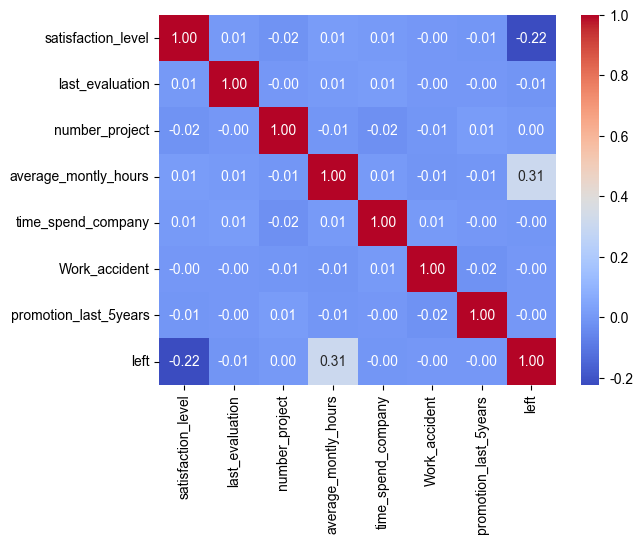

In [ ]:
# ✍️ 你的代码：EDA
import matplotlib.pyplot as plt
import seaborn as sns
# Mac 用户 (推荐):
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] 
# Windows 用户:
# plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

sns.heatmap(data= df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

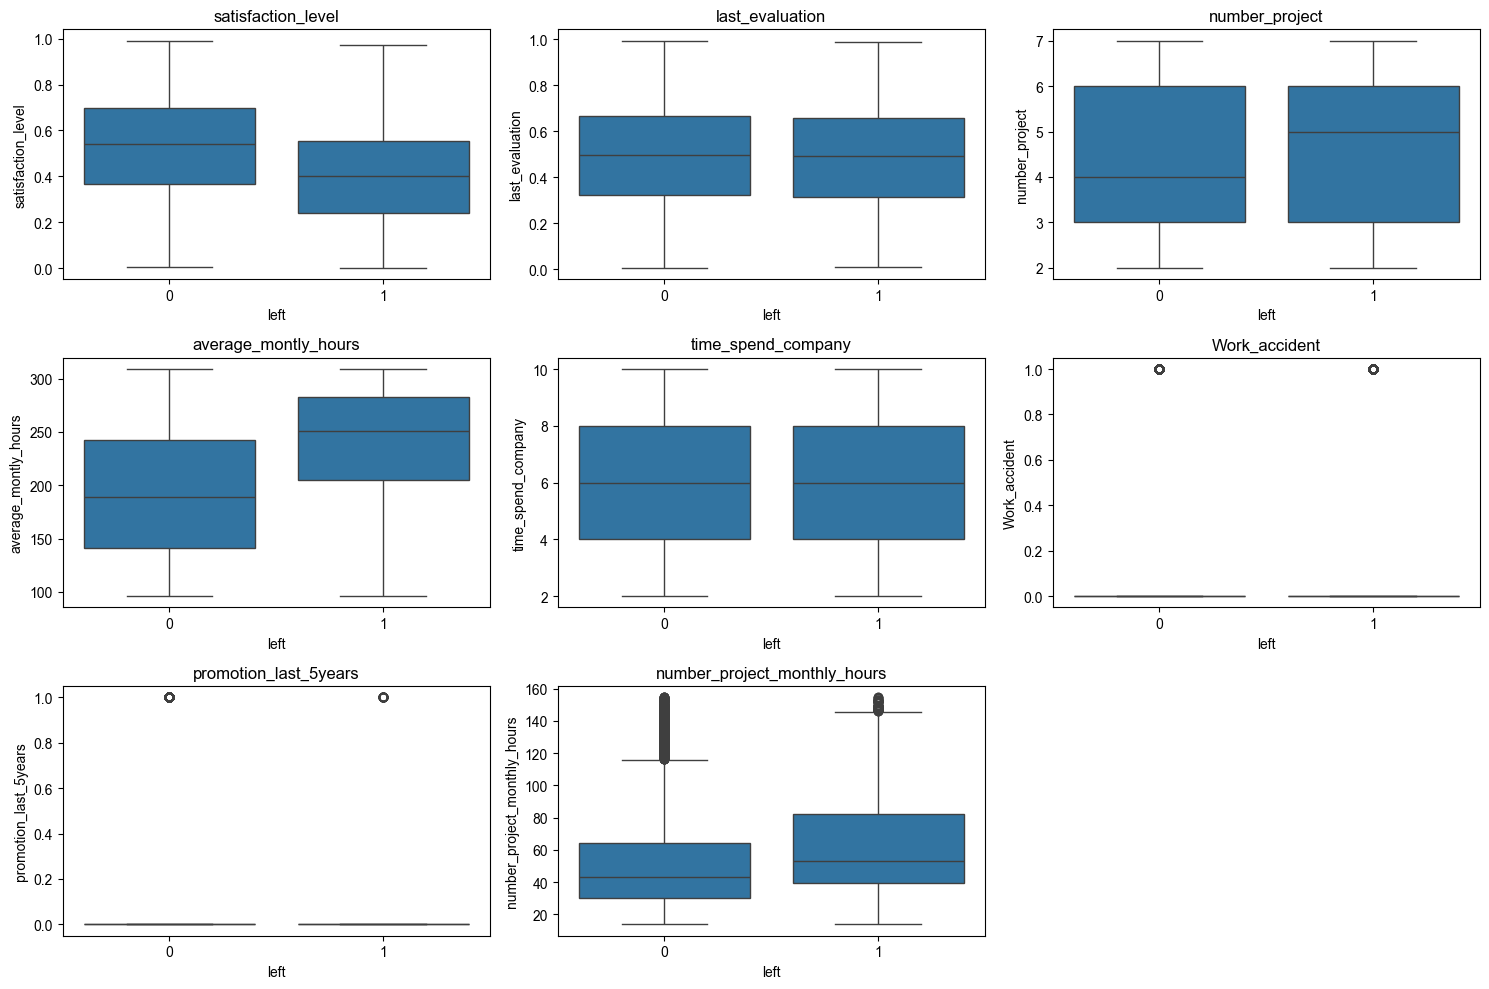

In [ ]:
df['number_project_monthly_hours'] = df['average_montly_hours']/df['number_project'] 
# 1. 自动筛选所有数值列 (排除掉 label)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'left' in num_cols: num_cols.remove('left')

# 2. 循环画图 (subplot)
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i+1) # 假设有9个变量，3x3排列
    sns.boxplot(data=df, x='left', y=col) # 对比 label=0/1 的分布差异
    plt.title(col)
plt.tight_layout()

找到 4 个强相关特征: ['satisfaction_level', 'average_montly_hours', 'number_project_monthly_hours', 'salary_high']


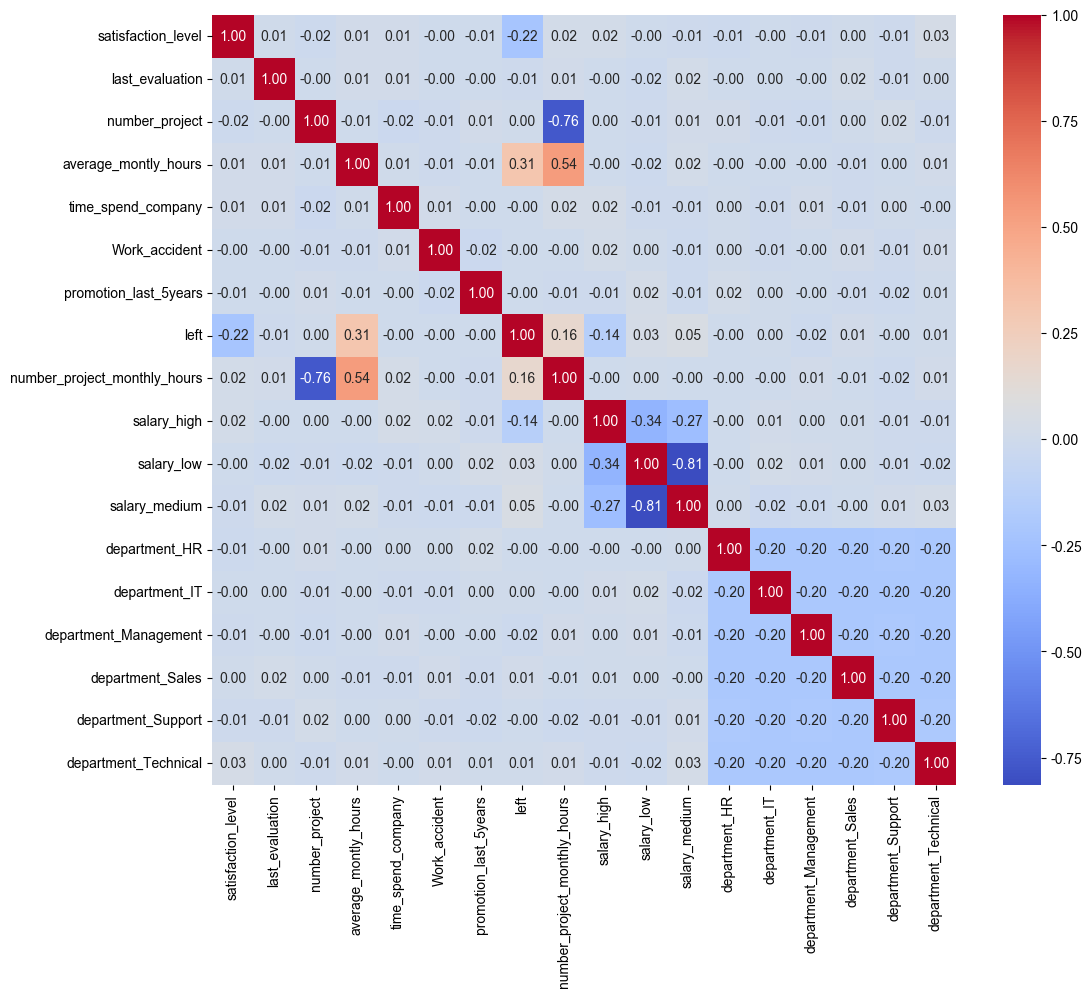

In [11]:
df_processed = pd.get_dummies(df,columns=['salary','department'])
plt.figure(figsize=(12, 10))
sns.heatmap(df_processed.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

# 1. 算出所有特征与 'left' (Target) 的相关系数
# .abs() 取绝对值，因为负相关 (-0.39) 也是强相关
correlations = df_processed.corr()['left'].abs()

# 2. 筛选出 > 0.1 的列，并且把 'left' 自己踢掉
# index.tolist() 把结果变成列表
high_corr_cols = correlations[correlations > 0.1].drop('left').index.tolist()

print(f"找到 {len(high_corr_cols)} 个强相关特征: {high_corr_cols}")

### 3. 特征工程 (Feature Engineering) 🔥
这是最考验你的一步！
**任务**：
1.  **处理分类变量**：`department` 和 `salary` 是文字，机器看不懂。请用 `pd.get_dummies` 把它们变成数字 (One-Hot Encoding)。
2.  **创造新特征** (发挥想象力)：
    *   比如：`evaluation / satisfaction` (性价比？)
    *   比如：`hours / project` (每个项目的平均工时，是不是效率低？)
3.  **标准化 (Scaling)**：别忘了把所有数值拉到同一个起跑线 (`StandardScaler`)。

### 数据字典 (Data Dictionary)
- **satisfaction_level**: 员工满意度 (0-1)
- **last_evaluation**: 上次绩效评分 (0-1)
- **number_project**: 负责的项目数量
- **average_montly_hours**: 平均月工作时长
- **time_spend_company**: 在公司呆了几年
- **Work_accident**: 是否发生过工伤 (0/1)
- **promotion_last_5years**: 过去5年是否升职 (0/1)
- **department**: 部门 (Sales, IT, HR, etc.)
- **salary**: 工资等级 (low, medium, high)
- **left**: **[Target]** 是否离职 (1=离职, 0=在职)

In [15]:
# ✍️ 你的代码：特征工程
from sklearn.preprocessing import StandardScaler

# 2. 标准化 (把所有数字拉回 0~1 的尺度)
scaler = StandardScaler()

# 这一步我们只缩放“数值型”的列，不缩放 0/1 的列
cols_to_scale = ['time_spend_company','average_montly_hours','number_project_monthly_hours','number_project']

# 这里的语法有点怪，但记下来就好：只改变选中的列
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# 3. 看看结果
print("特征工程完成！现在的 Mean 应该是 0 左右:")
df_processed[cols_to_scale].describe().round(2)
df_processed.describe()

特征工程完成！现在的 Mean 应该是 0 左右:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,left,number_project_monthly_hours
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.00000,10000.000000,1.000000e+04
mean,0.505068,0.494516,-1.243450e-17,1.136868e-17,-3.552714e-18,0.148400,0.02130,0.217400,9.592327e-18
std,0.222109,0.223897,1.000050e+00,1.000050e+00,1.000050e+00,0.355514,0.14439,0.412498,1.000050e+00
min,0.001511,0.006442,-1.450731e+00,-1.736491e+00,-1.550318e+00,0.000000,0.00000,0.000000,-1.312374e+00
25%,0.334265,0.319141,-8.678037e-01,-8.600640e-01,-7.740724e-01,0.000000,0.00000,0.000000,-7.147856e-01
50%,0.506285,0.495803,-2.848765e-01,1.330871e-04,2.173488e-03,0.000000,0.00000,0.000000,-2.897564e-01
75%,0.677991,0.665660,8.809778e-01,8.603301e-01,7.784194e-01,0.000000,0.00000,0.000000,4.587737e-01
max,0.990899,0.993858,1.463905e+00,1.720527e+00,1.554665e+00,1.000000,1.00000,1.000000,3.252926e+00


### 4. 模型训练 (Model Training)
**任务**：
1.  切分训练集和测试集 (80/20)，记得设 `random_state=42`。
2.  直接上 **Random Forest** (记得处理类别不平衡 `class_weight='balanced'`)。

In [16]:
# ✍️ 你的代码：训练模型
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


# 1. 准备 X (特征) 和 y (答案)
# 记得 drop 掉 'churn' (它是答案) 和 'user_id' (它是废话，对预测没用)
X = df_processed.drop(columns=['left']) 
y = df_processed['left']

# 2. 切分数据 (80% 训练，20% 考试)
# random_state=42 保证每次切分结果一样，方便复现 (42是宇宙终极答案 🌌)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("训练集形状 (老师教的):", X_train.shape)
print("测试集形状 (期末考试):", X_test.shape)



训练集形状 (老师教的): (8000, 17)
测试集形状 (期末考试): (2000, 17)


### 5. 结果解释 (Interpretation)
**任务**：
1.  打印 **Confusion Matrix**，看看我们抓住了多少离职员工？(关注 TP 和 Recall)
2.  画出 **Feature Importance**，告诉 HR 总监：**到底什么因素最影响员工离职？**

In [17]:
# ✍️ 你的代码：评估与解释
model = LogisticRegression()
model.fit(X_train,y_train)

# 4. 预测与评估 (Predict & Evaluate)
# 让它做考卷 (X_test)，也就是预测未来的用户会不会走
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"模型准确率: {accuracy:.2%}")


模型准确率: 80.85%


./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
./Library/Python/3.9/lib/python/site-

In [18]:

# ---------------------------------------------------------
# 5. 混淆矩阵 (Confusion Matrix) - 为什么只看准确率是不够的？
# ---------------------------------------------------------
# 准确率 (Accuracy) 只是一个总分 (e.g., 99分)。
# 混淆矩阵 (Confusion Matrix) 是 "试卷分析"：
# - 你到底是做错了选择题，还是做错了大题？
# - 你是把 "要走的人" 错判成了 "留下来" (放过坏人)？
# - 还是把 "留下来的人" 错判成了 "要走" (冤枉好人)？

cm = confusion_matrix(y_test, y_pred)
print("\n--- 混淆矩阵 (Confusion Matrix) ---")
print(cm)
print("-----------------------------------")
print("[[TN, FP],")
print(" [FN, TP]]")
# TN: 真没走 (预测没走，实际没走) - 答对了
# TP: 真走了 (预测走了，实际走了) - 答对了
# FP: 虚惊一场 (预测走了，实际没走) - 误报 (Type I Error)
# FN: 漏网之鱼 (预测没走，实际走了) - 漏报 (Type II Error) -> 这种最可怕！因为我们没挽留他。


--- 混淆矩阵 (Confusion Matrix) ---
[[1505   70]
 [ 313  112]]
-----------------------------------
[[TN, FP],
 [FN, TP]]


In [19]:
# 换个更猛的算法：随机森林
# n_estimators=100 表示请 100 棵树来投票
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 再次考试
y_pred_rf = rf_model.predict(X_test)

print(f"随机森林准确率: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\n--- 随机森林混淆矩阵 ---")
print(confusion_matrix(y_test, y_pred_rf))

# 看看这次能不能多抓几个？

随机森林准确率: 79.40%

--- 随机森林混淆矩阵 ---
[[1480   95]
 [ 317  108]]


In [20]:
# 🚀 必杀技：class_weight='balanced'
# 这会让模型对“流失用户”格外敏感
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)

y_pred_balanced = rf_balanced.predict(X_test)

print(f"加权随机森林准确率: {accuracy_score(y_test, y_pred_balanced):.2%}")
print("\n--- 加权混淆矩阵 (看看这次抓了多少？) ---")
print(confusion_matrix(y_test, y_pred_balanced))

加权随机森林准确率: 79.80%

--- 加权混淆矩阵 (看看这次抓了多少？) ---
[[1495   80]
 [ 324  101]]


/var/folders/35/q6rh83x91bzgf3gcsb_13f_80000gn/T/ipykernel_21622/3879649096.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


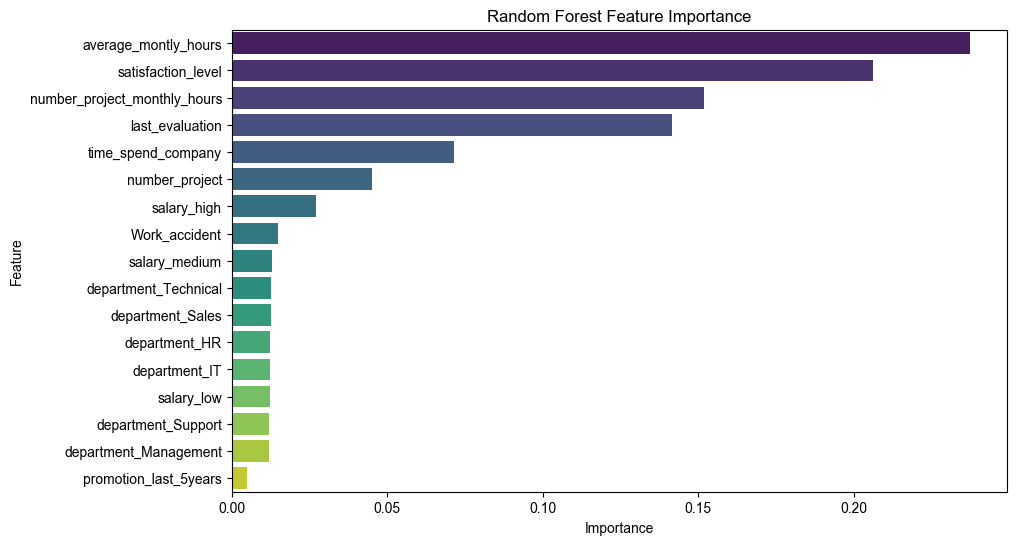

                        Feature  Importance
3          average_montly_hours    0.237433
0            satisfaction_level    0.206190
7  number_project_monthly_hours    0.151916
1               last_evaluation    0.141741
4            time_spend_company    0.071612


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 提取特征重要性
importances = rf_balanced.feature_importances_
feature_names = X.columns

# 做成一个 DataFrame 方便画图
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 画图
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.show()

# 打印前 5 名
print(feature_imp_df.head(5))

## 🏆 你的结论 (Actionable Insights)
写给 HR 总监的邮件：
1.  ...
2.  ...
3.  ...

---
# 📚 参考答案 & Senior DA 思路对比 (Reference Solution)

在你完成挑战后，可以参考下面的代码。
**Senior DA 的核心区别**：不只是跑模型，而是做**有业务含义的特征工程**和**深入的解释**。

### 1. 特征工程 (Feature Engineering)

In [ ]:
# 备份数据
df_model = df.copy()

# 1. 薪资有序编码 (Ordinal Encoding)
# 即使 salary 是 categorical，但它有大小关系 (low < medium < high)，所以不要用 One-Hot，用 Map 更好
salary_map = {'low': 1, 'medium': 2, 'high': 3}
df_model['salary_num'] = df_model['salary'].map(salary_map)
df_model.drop('salary', axis=1, inplace=True)

# 2. 部门 One-Hot 编码
df_model = pd.get_dummies(df_model, columns=['department'], drop_first=True)

# 3. ⭐️ 关键交互特征：Project * Hours (项目负荷)
# 直觉：项目多且工时长的，压力最大，最容易走
df_model['project_hours_interaction'] = df_model['number_project'] * df_model['average_montly_hours']

print("特征工程完成！New Shape:", df_model.shape)

### 2. 模型训练 (Model Training)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df_model.drop('left', axis=1)
y = df_model['left']

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ⭐️ 关键参数：class_weight='balanced'
# 因为离职的人通常是少数，必须加这个参数，让模型更重视“离职者”
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("--- 混淆矩阵 ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- 分类报告 ---")
print(classification_report(y_test, y_pred))

### 3. 先进的解释 (Interpretation)

In [ ]:
# 特征重要性可视化
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Top 10)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), X.columns[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 💡 Insight: 如果 'project_hours_interaction' 排名前列，说明'过劳'是主要驱动力。